# Data Wrangling and Performance Analysis for MLB Teams

This notebook demonstrates a full data wrangling workflow for
batting and pitching datasets, including cleaning, merging,
and exploratory analysis across multiple seasons.


In [ ]:
import pandas as pd
def parse_signups(raw):
    raw['name'] = raw['name'].str.title()
    raw['age'] = pd.to_numeric(raw['age'],errors='coerce')
    raw['signup_date'] = pd.to_datetime(raw['signup_date'],errors='coerce',format='mixed')
    return raw

In [ ]:
# Test code
import pandas as pd
raw = pd.DataFrame(
    [["Alice", "25", "April 25, 2025"],
    ["BOB", "Unknown", "2025-05-15"],
    ["Charlie", 24, "2025/5/20"],
    ["david", "23.5", "15th Sep. 2025"],
    ["EVe", "N/A", "2025.10.01"]],
    columns=["name", "age", "signup_date"],
)
print(parse_signups(raw))

## Extracting Product Attributes

In [ ]:
import pandas as pd
import re

def extract_attributes(data):
    df = data.copy()
    df[['Cat', 'Sub', 'ID']] = df['SKU'].str.split('-', expand=True)

    colors = ['Red', 'Green', 'Blue', 'Black', 'Yellow']
    size_map = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}

    def parse_desc(desc):
        color = None
        for c in colors:
            if re.search(rf'\b{c}\b', desc, re.IGNORECASE):
                color = c
                break
        size = None
        size_match = re.search(r'size[:\s\-()]*\b(Small|Medium|Large)\b', desc, re.IGNORECASE)
        if size_match:
            size = size_match.group(1).capitalize()
        else:
            size_match = re.search(r'size[:\s\-()]*\b([SML])\b', desc, re.IGNORECASE)
            if size_match:
                s = size_match.group(1).upper()
                size = size_map.get(s)
        price_match = re.search(r'\$([\d\.]+)', desc)
        price = float(price_match.group(1)) if price_match else None
        prod = desc
        if color:
            prod = re.sub(rf'\b{color}\b', '', prod, flags=re.IGNORECASE)
        prod = re.sub(r'\(.*?\)', '', prod)
        prod = re.sub(r'size[:\s\-()]*\b(Small|Medium|Large|[SML])\b', '', prod, flags=re.IGNORECASE)
        prod = re.sub(r'\$[\d\.]+', '', prod)
        prod = re.sub(r'[-:]', ' ', prod)
        prod = re.sub(r'\s+', ' ', prod).strip()
        prod = prod.title()
        prod = prod.replace('T Shirt', 'T-Shirt')
        return pd.Series([color, size, price, prod])
    df[['Color', 'Size', 'Price', 'Product']] = df['Description'].apply(parse_desc)
    df = df[['SKU', 'Cat', 'Sub', 'ID', 'Product', 'Color', 'Size', 'Price']]
    return df

In [ ]:
# Test case 1
import pandas as pd

data = {"SKU": ["APP-TOP-001", "APP-BOT-002", "ACC-HAT-003", "APP-OUT-004", "APP-DRS-005", "ACC-BOT-002"],
"Description": [
"Red T-Shirt (Size: M) - $19.99",
"blue jeans - size: large - $45.00",
"HAT BLACK (Size: L) $12.50",
"Green Sweater $9.50",
"Yellow Dress (size: S) - $34.99",
"Dress Shirt Blue Size: M $50.00",
]}
df = pd.DataFrame(data)
print(extract_attributes(df))

           SKU  Cat  Sub   ID      Product   Color    Size  Price
0  APP-TOP-001  APP  TOP  001      T-Shirt     Red  Medium  19.99
1  APP-BOT-002  APP  BOT  002        Jeans    Blue   Large  45.00
2  ACC-HAT-003  ACC  HAT  003          Hat   Black   Large  12.50
3  APP-OUT-004  APP  OUT  004      Sweater   Green    None   9.50
4  APP-DRS-005  APP  DRS  005        Dress  Yellow   Small  34.99
5  ACC-BOT-002  ACC  BOT  002  Dress Shirt    Blue  Medium  50.00


In [ ]:
# Test case 2
data = {"SKU": ["CLO-SHR-101", "FOO-SNK-202", "CLO-PNT-303", "ACC-SCF-404", "CLO-JAK-505", "SPT-SHO-606"], "Description": ["blue polo shirt (size: m) $29.99", "green apple snacks - size: l - $4.50", "black dress pants size: s $55.00", "red wool scarf $18", "yellow rain jacket", "running shoes (size: m) $75.50"]}
print(extract_attributes(pd.DataFrame(data)))

           SKU  Cat  Sub   ID        Product   Color    Size  Price
0  CLO-SHR-101  CLO  SHR  101     Polo Shirt    Blue  Medium  29.99
1  FOO-SNK-202  FOO  SNK  202   Apple Snacks   Green   Large   4.50
2  CLO-PNT-303  CLO  PNT  303    Dress Pants   Black   Small  55.00
3  ACC-SCF-404  ACC  SCF  404     Wool Scarf     Red    None  18.00
4  CLO-JAK-505  CLO  JAK  505    Rain Jacket  Yellow    None    NaN
5  SPT-SHO-606  SPT  SHO  606  Running Shoes    None  Medium  75.50


### Correct Output:
```
           SKU  Cat  Sub   ID        Product   Color    Size  Price
0  CLO-SHR-101  CLO  SHR  101     Polo Shirt    Blue  Medium  29.99
1  FOO-SNK-202  FOO  SNK  202   Apple Snacks   Green   Large   4.50
2  CLO-PNT-303  CLO  PNT  303    Dress Pants   Black   Small  55.00
3  ACC-SCF-404  ACC  SCF  404     Wool Scarf     Red     NaN  18.00
4  CLO-JAK-505  CLO  JAK  505    Rain Jacket  Yellow     NaN    NaN
5  SPT-SHO-606  SPT  SHO  606  Running Shoes     NaN  Medium  75.50
```

## Standardizing Customer Data

In [ ]:
import pandas as pd
import numpy as np
import re

def clean_customer_data(raw):
    df = raw.copy()
    df['order'] = df['order_id'].str.replace('ORD', '', regex=False).astype(int)
    def extract_names(name):
        if pd.isna(name) or name in ['N/A', 'None']:
            return pd.Series([np.nan, np.nan])
        parts = [p.strip() for p in name.split(',')]
        if len(parts) == 2:
            last = parts[0].title()
            first = parts[1].title()
            return pd.Series([first, last])
        else:
            return pd.Series([np.nan, np.nan])
    
    df[['first', 'last']] = df['customer_name'].apply(extract_names)
    
    df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce',format = 'mixed')
    
    def clean_amount(amount):
        if pd.isna(amount) or amount in ['N/A', 'None']:
            return np.nan
        cleaned = str(amount).replace('$', '').replace(',', '')
        try:
            return float(cleaned)
        except:
            return np.nan
    
    df['amount'] = df['amount'].apply(clean_amount)
    
    def clean_email(email):
        if pd.isna(email) or email in ['N/A', 'None']:
            return np.nan
        return str(email).lower().strip()
    
    df['email'] = df['email'].apply(clean_email)
    
    def is_usc(email):
        if pd.isna(email):
            return np.nan
        return email.endswith('usc.edu')
    
    df['USC'] = df['email'].apply(is_usc)
    
    result = df[['order', 'first', 'last', 'order_date', 'amount', 'email', 'USC']]
    result = result.set_index('order').sort_index()
    
    return result


In [ ]:
# Test case 1
import pandas as pd
raw = pd.DataFrame({
"order_id": ["ORD011", "ORD012", "ORD013", "ORD015", "ORD022"],
"customer_name": [" Doe  , John ", " SMITH  , jane", "Johnson,Bob", "N/A", "Wong,ALICE"],
"order_date": ["2024-01-15", "01/16/2024", "2024.01.17", "2024-01-18", "2024-01-19"],
"amount": ["$1,250.5", "2300.75", "$850", "1,500", "$3,200.25"],
"email": ["john@usc.edu ", "jane@gmail.com", "bob@USC.EDU", "test@YaHoo.Com", "None"]
})
cleaned = clean_customer_data(raw)
print(cleaned)

       first     last order_date   amount           email    USC
order                                                           
11      John      Doe 2024-01-15  1250.50    john@usc.edu   True
12      Jane    Smith 2024-01-16  2300.75  jane@gmail.com  False
13       Bob  Johnson 2024-01-17   850.00     bob@usc.edu   True
15       NaN      NaN 2024-01-18  1500.00  test@yahoo.com  False
22     Alice     Wong 2024-01-19  3200.25             NaN    NaN


In [ ]:
# Test case 2
raw2 = pd.DataFrame({
"order_id": ["ORD099", "ORD101", "ORD105", "ORD110", "ORD115"],
"customer_name": ["Durant ,Kevin", "N/A", "Carter,Alice", "Brown , Charlie ", "LEE,SARA"],
"order_date": ["2025-05-20", "06/01/2025", "2025.06.03", "June 6, 2025", "2025/6/15"],
"amount": ["$1500", "2,000.50", "$750", "$1,250", "$3,300"],
"email": ["durant@nba.com", "N/A", "alice.carter@usc.EDU", "cbrown@marshall.usc.edu", "SAUSC@gmail.com"]
})
print(clean_customer_data(raw2))

         first    last order_date  amount                    email    USC
order                                                                    
99       Kevin  Durant 2025-05-20  1500.0           durant@nba.com  False
101        NaN     NaN 2025-06-01  2000.5                      NaN    NaN
105      Alice  Carter 2025-06-03   750.0     alice.carter@usc.edu   True
110    Charlie   Brown 2025-06-06  1250.0  cbrown@marshall.usc.edu   True
115       Sara     Lee 2025-06-15  3300.0          sausc@gmail.com  False


## Parsing Contact Information


In [ ]:
import pandas as pd
import numpy as np
import re

def parse_contact(raw):
    data = []
    
    for entry in raw:

        entry = entry.replace('|', ',').replace(' - ', ',')
        parts = [p.strip() for p in entry.split(',')]

        name = parts[0] if len(parts) > 0 else np.nan

        email = np.nan
        for part in parts:
            if '@' in part:
                email = part
                break
 
        phone = np.nan
        for part in parts:
            phone_match = re.search(r'[\d\(\)\-]+', part)
            if phone_match and len(re.findall(r'\d', part)) >= 10:
                phone = part.strip()
                break
        
        state = np.nan
        for part in parts:
            state_match = re.search(r'\b([A-Z]{2})\b', part)
            if state_match:
                state = state_match.group(1)
                break

        address_parts = []
        for i, part in enumerate(parts):
            if i == 0:
                continue
            if '@' in part:
                continue
            if not pd.isna(phone) and phone in part:
                continue
            address_parts.append(part)
        
        address = ', '.join(address_parts) if address_parts else np.nan
        if not pd.isna(address):
            address = re.sub(r'\s+', ' ', address).strip()
        
        data.append({
            'Name': name,
            'Email': email,
            'Phone': phone,
            'State': state,
            'Address': address
        })
    
    df = pd.DataFrame(data)
    return df


In [ ]:
# Test case 1
import pandas as pd

raw = pd.Series([
"A. Johnson, 123 Main St, Boston, MA 02101, 617-555-1234, alice@email.com",
"B. Smith, 456 Oak Ave, Chicago, IL 60601|bob.smith@company.com|(312)5555678",
"Carol White, 789 Elm Dr, Seattle, WA cwhite@usc.edu",
"David G. Lee, 321 Pine Rd, Austin, TX - david@mail.com - (213)555-3456",
"Emma Brown, emma.jones@web.net, 555 Sunset Blvd, Apt 12, Los Angeles, CA,  213-555-3456"
])
print(parse_contact(raw))

           Name                  Email          Phone State  \
0    A. Johnson        alice@email.com   617-555-1234    MA   
1      B. Smith  bob.smith@company.com   (312)5555678    IL   
2   Carol White      WA cwhite@usc.edu            NaN    WA   
3  David G. Lee         david@mail.com  (213)555-3456    TX   
4    Emma Brown     emma.jones@web.net   213-555-3456    CA   

                                    Address  
0             123 Main St, Boston, MA 02101  
1            456 Oak Ave, Chicago, IL 60601  
2                       789 Elm Dr, Seattle  
3                   321 Pine Rd, Austin, TX  
4  555 Sunset Blvd, Apt 12, Los Angeles, CA  


In [ ]:
# Test case 2
raw = pd.Series([
"Susan Martinez, 789 Broadway Ave, New York, NY, (212)555-8901, susan.m@corp.com",
"M.C. Johnson, 234 Lake Dr, Seattle, WA, mark.johnson@tech.net, 206-555-3421",
"Angela Chen, 567 Park Blvd, San Francisco, CA 94102 -- angela.chen@startup.io",
"Raj Sharma, (512)555-7654, 890 Hill St, Austin, TX, rwilliams@gmail.com",
"J. Davis, 123 River Rd, Portland, OR 97201",
"Patrick O'Brien, 456 Ocean Way, Miami, FL 33101 | 305-555-2109 | pobrien@usc.edu",
"Maria Garcia-Lopez, 678 Desert View, Phoenix, AZ - (602)555-4433 - mgl@company.org"
])
print(parse_contact(raw))

                 Name                               Email          Phone  \
0      Susan Martinez                    susan.m@corp.com  (212)555-8901   
1        M.C. Johnson               mark.johnson@tech.net   206-555-3421   
2         Angela Chen  CA 94102 -- angela.chen@startup.io            NaN   
3          Raj Sharma                 rwilliams@gmail.com  (512)555-7654   
4            J. Davis                                 NaN            NaN   
5     Patrick O'Brien                     pobrien@usc.edu   305-555-2109   
6  Maria Garcia-Lopez                     mgl@company.org  (602)555-4433   

  State                           Address  
0    NY    789 Broadway Ave, New York, NY  
1    WA          234 Lake Dr, Seattle, WA  
2    CA      567 Park Blvd, San Francisco  
3    TX           890 Hill St, Austin, TX  
4    OR  123 River Rd, Portland, OR 97201  
5    FL    456 Ocean Way, Miami, FL 33101  
6    AZ      678 Desert View, Phoenix, AZ  


## Analyzing Retail Sales


In [ ]:
def analyze_sales (q1_sales, q2_sales, products, customers):
    sales = pd.concat([q1_sales,q2_sales],ignore_index=1)
    sales_prodcuts = sales.merge(products,on='product_id',how='left')
    final = sales_prodcuts.merge(customers,on='customer_id',how='left')
    final['revenue'] = final['quantity']*final['price']
    summary = (
            final.groupby('loyalty_tier', as_index=False)
            .agg(
                Total_Revenue=('revenue', 'sum'),
                Total_Sales=('quantity', 'sum'),
                Unique_Customers=('customer_id', 'nunique')
            )
        )
    return final,summary

In [ ]:
# Test case
import pandas as pd
q1_sales = pd.DataFrame({
    "order_id": [101, 102, 103, 104],
    "customer_id": ["C001", "C002", "C003", "C001"],
    "product_id": ["P10", "P20", "P10", "P30"],
    "quantity": [2, 1, 3, 1]
})
q2_sales = pd.DataFrame({
    "order_id": [201, 202, 203],
    "customer_id": ["C002", "C004", "C003"],
    "product_id": ["P30", "P20", "P10"],
    "quantity": [2, 4, 1]
})
products = pd.DataFrame({
    "product_id": ["P10", "P20", "P30"],
    "product_name": ["Laptop", "Mouse", "Keyboard"],
    "price": [999.99, 29.99, 79.99]
})
customers = pd.DataFrame({
    "customer_id": ["C001", "C002", "C003", "C004"],
    "customer_name": ["Alice", "Bob", "Charlie", "Diana"],
    "loyalty_tier": ["Gold", "Silver", "Gold", "Bronze"]
})
sales_complete, summary = analyze_sales(q1_sales, q2_sales, products, customers)
print("--- COMPLETE SALES DATA ---")
print(sales_complete)
print("\n--- SUMMARY BY LOYALTY TIER ---")
print(summary)

--- COMPLETE SALES DATA ---
   order_id customer_id product_id  quantity product_name   price  \
0       101        C001        P10         2       Laptop  999.99   
1       102        C002        P20         1        Mouse   29.99   
2       103        C003        P10         3       Laptop  999.99   
3       104        C001        P30         1     Keyboard   79.99   
4       201        C002        P30         2     Keyboard   79.99   
5       202        C004        P20         4        Mouse   29.99   
6       203        C003        P10         1       Laptop  999.99   

  customer_name loyalty_tier  revenue  
0         Alice         Gold  1999.98  
1           Bob       Silver    29.99  
2       Charlie         Gold  2999.97  
3         Alice         Gold    79.99  
4           Bob       Silver   159.98  
5         Diana       Bronze   119.96  
6       Charlie         Gold   999.99  

--- SUMMARY BY LOYALTY TIER ---
  loyalty_tier  Total_Revenue  Total_Sales  Unique_Customers
0    

## Updating Dodger Datasets

In [ ]:
import pandas as pd
import re
def updated_data(old_file, new_files, column_mapping):
    old_df = pd.read_csv(old_file)
    new_dfs = []
    for year, file in new_files:
        df = pd.read_csv(file)
        df['Year'] = year
        new_dfs.append(df)
    combined_new = pd.concat(new_dfs, ignore_index=True)

    def extract_hand(name):
        if isinstance(name, str):
            if name.endswith('*'):
                return 'Left'
            elif name.endswith('#'):
                return 'Both'
            else:
                return 'Right'
        return None

    def clean_name(name):
        if isinstance(name, str):
            return re.sub(r'[\*#]', '', name).strip()
        return name

    combined_new['Dominant_Hand'] = combined_new['Player'].apply(extract_hand)
    combined_new['Player'] = combined_new['Player'].apply(clean_name)
    combined_new = combined_new.rename(columns=column_mapping)
    combined_all = pd.concat([old_df, combined_new], ignore_index=True)
    combined_all = combined_all.sort_values(by=['Year', 'Rank'], ascending=[False, True]).reset_index(drop=True)

    return combined_all

    

In [ ]:
# Test case 1 
old_file = "09-LAD_batting.csv"
new_files = [(2024, "10-batting-24.csv"), (2025, "10-batting-25.csv")]
column_mapping = {
    'Rk': 'Rank', 'Player': 'Name', 'Age': 'Age', 'Pos': 'Position', 
    'G': 'Games', 'PA': 'Plate_Appearances', 'AB': 'At_Bats', 'R': 'Runs', 
    'H': 'Hits', '2B': 'Doubles', '3B': 'Triples', 'HR': 'Home_Runs', 
    'RBI': 'Runs_Batted_In', 'SB': 'Stolen_Bases', 'CS': 'Caught_Stealing', 
    'BB': 'Base_On_Balls', 'SO': 'Strikeouts', 'BA': 'Batting_Average', 
    'OBP': 'On_Base_Percentage', 'SLG': 'Slugging_Percentage', 
    'OPS': 'On_Base_Plus_Slugging_Percentage', 
    'OPS+': 'On_Base_Plus_Slugging_Percentage_Plus', 'TB': 'Total_Bases', 
    'GIDP': 'Double_Plays_Grounded_Into', 'HBP': 'Times_Hit_By_Pitch', 
    'SH': 'Sacrifice_Hits', 'SF': 'Sacrifice_Flies', 
    'IBB': 'Intentional_Bases_on_Balls'
}
df=updated_data(old_file, new_files, column_mapping)
print(df[['Year', 'Rank', 'Position', 'Name', 'Age', 'Total_Bases', 'Dominant_Hand']])
df.to_csv('10-LAD_batting-updated.csv', index=False)

      Year  Rank Position             Name  Age  Total_Bases Dominant_Hand
0     2025     1        C       Will Smith   30          180         Right
1     2025     2       1B  Freddie Freeman   35          279          Left
2     2025     3       2B      Tommy Edman   30          132          Both
3     2025     4       SS     Mookie Betts   32          239         Right
4     2025     5       3B        Max Muncy   34          147          Left
...    ...   ...      ...              ...  ...          ...           ...
2802  1958    39        P  Ralph Mauriello   23            0         Right
2803  1958    40        P      Don Bessent   27            0         Right
2804  1958    41        P       Ron Negray   28            0         Right
2805  1958    42        P    Jackie Collum   31            0          Left
2806  1958    43        P     Larry Sherry   22            0         Right

[2807 rows x 7 columns]


In [ ]:
# Test case 2
old_file = "09-LAD_pitching.csv"
new_files = [(2024, "10-pitching-24.csv"), (2025, "10-pitching-25.csv")]
column_mapping = {
    'Rk': 'Rank', 'Player': 'Name', 'Age': 'Age', 'Pos': 'Position',
    'W': 'Wins', 'L': 'Losses', 'W-L%': 'Winning_Percentage',
    'ERA': 'Earned_Run_Average', 'G': 'Games_Played', 'GS': 'Games_Started',
    'GF': 'Games_Finished', 'CG': 'Complete_Games', 'SHO': 'Shutouts',
    'SV': 'Saves', 'IP': 'Innings_Pitched', 'H': 'Hits_Allowed',
    'R': 'Runs_Allowed', 'ER': 'Earned_Runs', 'HR': 'Home_Runs_Allowed',
    'BB': 'Walks_Allowed', 'IBB': 'Intentional_Walks_Allowed', 'SO': 'Strikeouts',
    'HBP': 'Hit_By_Pitch', 'BK': 'Balks', 'WP': 'Wild_Pitches',
    'BF': 'Batters_Faced', 'ERA+': 'Adjusted_Earned_Run_Average',
    'FIP': 'Fielding_Independent_Pitching', 'WHIP': 'Walks_Hits_Per_Inning_Pitched',
    'H9': 'Hits_Per_Nine_Innings', 'HR9': 'Home_Runs_Per_Nine_Innings',
    'BB9': 'Walks_Per_Nine_Innings', 'SO9': 'Strikeouts_Per_Nine_Innings',
    'SO/BB': 'Strikeout_Walk_Ratio'
}
df=updated_data(old_file, new_files, column_mapping)
print(df[['Year', 'Rank', 'Name', 'Age', 'Wins', 'Strikeouts', 'Dominant_Hand']])
df.to_csv('10-LAD_pitching-updated.csv', index=False)

      Year  Rank                Name  Age  Wins  Strikeouts Dominant_Hand
0     2025     1  Yoshinobu Yamamoto   26    12         201         Right
1     2025     2     Clayton Kershaw   37    11          84          Left
2     2025     3          Dustin May   27     6          97         Right
3     2025     4       Tyler Glasnow   31     4         106         Right
4     2025     5       Emmet Sheehan   25     6          89         Right
...    ...   ...                 ...  ...   ...         ...           ...
1328  1958    15         Don Bessent   27     1          13         Right
1329  1958    16     Ralph Mauriello   23     1          11         Right
1330  1958    17          Ron Negray   28     0           2         Right
1331  1958    18        Larry Sherry   22     0           2         Right
1332  1958    19       Jackie Collum   31     0           0          Left

[1333 rows x 7 columns]


## Life Expectancy by Continent

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/chendaniely/pandas_for_everyone/master/data/gapminder.tsv"
gapminder = pd.read_csv(url, sep="\t")

/var/folders/d_/_clmqlv10ng29010mqhj7jzc0000gn/T/ipykernel_60927/3920960911.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['lifeExp'] * g['pop']).sum() / g['pop'].sum())


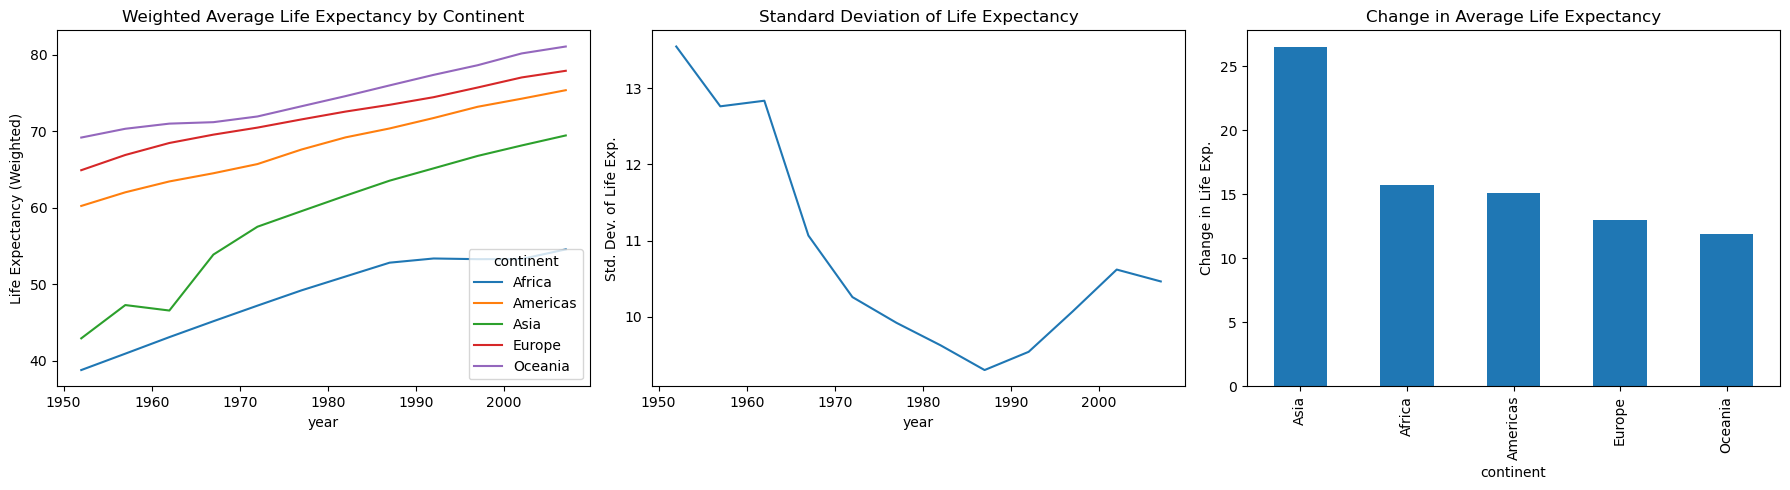

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

weighted = (
    gapminder
    .groupby(['continent', 'year'], group_keys=False)
    .apply(lambda g: (g['lifeExp'] * g['pop']).sum() / g['pop'].sum())
    .reset_index(name='lifeExp_weighted')
)

change = weighted.groupby('continent')['lifeExp_weighted'].agg(['first', 'last'])
change['change'] = change['last'] - change['first']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

weighted.pivot(index='year', columns='continent', values='lifeExp_weighted').plot(
    title='Weighted Average Life Expectancy by Continent',
    ax=axes[0]
)
axes[0].set_ylabel('Life Expectancy (Weighted)')

weighted.groupby('year')['lifeExp_weighted'].std().plot(
    title='Standard Deviation of Life Expectancy',
    ax=axes[1]
)
axes[1].set_ylabel('Std. Dev. of Life Exp.')

change.sort_values('change', ascending=False)['change'].plot(
    kind='bar',
    title='Change in Average Life Expectancy',
    ax=axes[2]
)
axes[2].set_ylabel('Change in Life Exp.')

plt.tight_layout()
plt.show()


## Two-Way Players in Dodgers History


In [ ]:
import pandas as pd

batting = pd.read_csv("10-LAD_batting-updated.csv")
pitching = pd.read_csv("10-LAD_pitching-updated.csv")

bat_cols = ['Year', 'Name', 'Rank', 'Runs']
pit_cols = ['Year', 'Name', 'Rank', 'Strikeouts']

bat_df = batting[bat_cols].rename(columns={'Rank': 'Batting_Rank'})
pit_df = pitching[pit_cols].rename(columns={'Rank': 'Pitching_Rank'})

merged = pd.merge(bat_df, pit_df, on=['Year', 'Name'], how='inner')

two_way = merged[(merged['Runs'] >= 10) & (merged['Strikeouts'] >= 10)]

two_way['Combined_Rank'] = two_way['Batting_Rank'] + two_way['Pitching_Rank']
top7 = two_way.sort_values(by=['Combined_Rank']).head(7)

print(top7[['Year', 'Name', 'Batting_Rank', 'Pitching_Rank', 'Runs', 'Strikeouts']])



      Year              Name  Batting_Rank  Pitching_Rank  Runs  Strikeouts
0     2025     Shohei Ohtani             9              6   146          62
1161  1964      Don Drysdale            20              1    10         237
731   1993    Orel Hershiser            21              1    11         141
1022  1974  Andy Messersmith            23              1    12         221
1149  1965      Don Drysdale            22              2    18         210
1078  1970     Claude Osteen            23              2    10         114
359   2011   Clayton Kershaw            28              1    10         248


/var/folders/d_/_clmqlv10ng29010mqhj7jzc0000gn/T/ipykernel_60927/42485418.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  two_way['Combined_Rank'] = two_way['Batting_Rank'] + two_way['Pitching_Rank']
